# 0. Введение.

Привет! Эта лабораторная работа про то, какие есть способы сбора данных с сайтов. Давай начнём с небольшого введения про то, как её выполнять.

В коде и тексте этой лабораторной работы встречаются блоки двух видов. Первый из них будет в ячейках с кодом и выглядит он так:


```
# TODO
```

Это означает, что тут надо написать одну или несколько строчек кода.

Второй тип блоков выглядит так - <font color='violet'> \# TODO </font>. Он означает, что тут надо написать какие-то свои мысли и выводы. Когда будешь писать, пожалуйста, не меняй цвет текста твоего ответа - это упростит проверку.

В тексте внизу собраны все нужные библиотечки - запускаем её и начинаем выполнение лабораторной работы! :)

In [1]:
from urllib.request import urlopen
from urllib.parse import urlparse, urldefrag, urljoin
from bs4 import BeautifulSoup
import requests
import pandas as pd
import re
import json

# Часть 1. Работа со статическими страницами при помощи bs4. 3 балла.



В этой части вам не нужно работать с маркетплейсами или сложными крупными онлайн-магазинами, достаточно поиграться с **небольшим нишевым магазинчиком**.

Пример сайта, подходящего под задание:
- Семена овощей - Аэлита https://ailita-shop.ru/


Вам нужно найти ПОХОЖИЙ сайт без динамической подгрузки контента (таких в интернете очень много)

Для формирования представления о магазине достаточно посмотреть на товары одной выбранной категории.

На странице товара **должна содержалась следующая информация, которую вам надо будет получить в рамках задания**:

- Название
- Картинка
- Характеристики (минимум 1)
- Описание

Описание должно быть достаточно большим (больше одного предложения) и содержать информацию о характеристиках товара. Например, как это бывает на алиэкспрессе

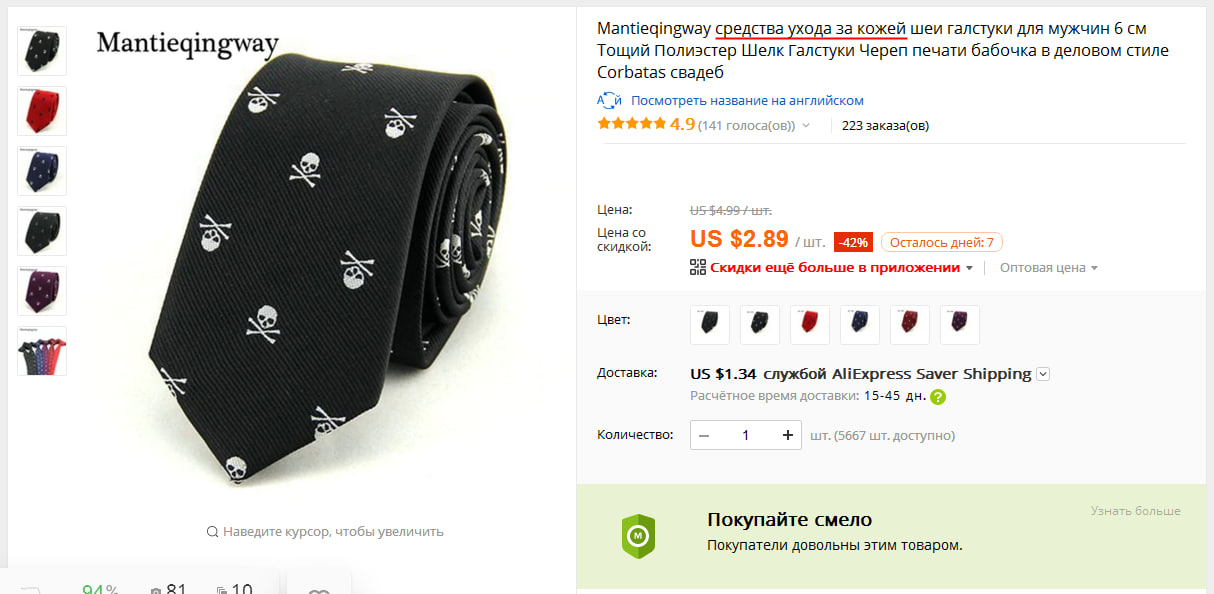

## Исследование

Выберите магазин, который удовлетворяет описанию магазина-конкурента:

<font color='violet'> \# TODO https://top3dshop.ru/</font>

Выберите категорию товаров и посмотрите на предлагаемые карточки товаров. **Категория должна содержать 20+ карточек, чтобы можно было составить более полное мнение о товарах в магазине.**

In [2]:
url = 'https://top3dshop.ru/kupit-3d-printer/'#TODO

Откройте ссылку с помощью библиотеки `urllib` и загрузите данные в переменную `html`. Не забудь про кодировку!

In [3]:
html = urlopen(url).read().decode()#TODO

Распарсьте текстовую информация на странице, используя библиотеку `bs4`



In [4]:
soup = BeautifulSoup(html, "html.parser")#TODO

Найдите все узлы href на странице

In [5]:
hrefs = soup.find_all("a", href=True)#TODO

Сохраните полные адреса сслыкок в список


Подсказка: используйте `urljoin`

In [6]:
links = [urljoin(url, href['href']) for href in hrefs]#TODO

Какие ссылки соответствуют карточкам товаров? Выберите все такие ссылки. Для этого напишем функцию фильтрации, которая будет определять, является ли ссылка корректной

In [7]:
#TODO
from re import match
def filter(links):
    return [link for link in links if match(r'https://top3dshop.ru/kupit-3d-printer/[a-zA-Z0-9\-\.]+$', link) is not None]

In [8]:
filtered_links = filter(links)
filtered_links

['https://top3dshop.ru/kupit-3d-printer/f2-innovations-lite.html',
 'https://top3dshop.ru/kupit-3d-printer/f2-innovations-lite.html',
 'https://top3dshop.ru/kupit-3d-printer/zbolt-s410-dual.html',
 'https://top3dshop.ru/kupit-3d-printer/zbolt-s410-dual.html',
 'https://top3dshop.ru/kupit-3d-printer/3d-apex-maker-x1.html',
 'https://top3dshop.ru/kupit-3d-printer/3d-apex-maker-x1.html',
 'https://top3dshop.ru/kupit-3d-printer/stereotech-hybrid-530-v5.html',
 'https://top3dshop.ru/kupit-3d-printer/stereotech-hybrid-530-v5.html',
 'https://top3dshop.ru/kupit-3d-printer/rokit-invivo.html',
 'https://top3dshop.ru/kupit-3d-printer/rokit-invivo.html',
 'https://top3dshop.ru/kupit-3d-printer/zbolt-s310-dual.html',
 'https://top3dshop.ru/kupit-3d-printer/zbolt-s310-dual.html',
 'https://top3dshop.ru/kupit-3d-printer/3d-apex-maker-x2.html',
 'https://top3dshop.ru/kupit-3d-printer/3d-apex-maker-x2.html',
 'https://top3dshop.ru/kupit-3d-printer/f2-kubo.html',
 'https://top3dshop.ru/kupit-3d-printer

 На странице могло быть несколько ссылок, ведущих на одну и ту же карточку товара. Избавьтесь от дубликатов в списке ссылок

Сколько получилось ссылок?

In [9]:
filtered_links = list(set(filtered_links))#TODO
len(filtered_links)

24

Теперь, когда у нас есть ссылки на товары, давайте проанализируем, что этот магазин продает. Откройте страницу товара и посмотрите, какая информация там представлена и какую информацию вы хотите сохранить. **Обязательные** колонки:

- Название
- Картинка
- Характеристики (минимум 1) - для одежды это может быть ткань, из которой  она сшита, для семян овощей - срок созревания и.т.д.
- Описание

Можно **(и даже стоит)** добавить больше колонок, если получается выгрузить такую информацию.

In [10]:
columns = ['name', 'image', 'description', 'manufacturer', 'model', 'type','power']#TODO

Напишите функцию, которая принимает ссылку на страницу и возвращает все необходимые признаки. Для этого давайте поймем, как работать сначала с одной ссылкой

Выберите первую ссылку из списка

In [11]:
first_link = filtered_links[0] #TODO

Распечатайте ее

In [12]:
first_link#TODO

'https://top3dshop.ru/kupit-3d-printer/f2-kubo.html'

Используя библиотеку `requests` загрузите данные по сслыке и распартье их, как вы это делали ранее

In [13]:
response = requests.get(first_link)#TODO
soup = BeautifulSoup(response.content, 'html')#TODO

Посмотрите на полученные данные. В каком узле находится название товара? Сохраните этот узел и достаньте название товара

In [14]:
#TODO
product_name = soup.find('h1', class_="product__name").contents[0].strip()
product_name

'3D принтер F2 Kubo'

Проделайте аналогичные шаги, чтобы получить информацию для оставшихся колонок

In [15]:
features_divs = soup.find_all('div', class_="product__feature")#TODO
features= [feature.findChild(class_="product__feature-value").text.strip() for feature in features_divs][:3]

In [16]:
features

['F2 innovations', 'F2 Kubo', 'FDM']

In [17]:
img = soup.find('img', itemprop="image").attrs['src']
img

'https://top3dshop.ru/image/cache/data/products/printers/f2/kubo/f2_kubo_1-500x500.png'

Достаньте описание товара

In [18]:
description = soup.find('div', itemprop="description").text#TODO

In [19]:
description

'\n\n\nПредставляем вам 3D принтер F2 Kubo — идеальное решение для всех, кто стремится воплотить свои идеи в жизнь с максимальной точностью и качеством. Этот принтер сочетает в себе передовые технологии, надежность и простоту использования, что делает его идеальным выбором как для новичков, так и для опытных пользователей.\nПреимущества 3D-принтера F2 Kubo\nПрофессиональное качество печати\nF2 Kubo оснащен высококачественной экструдерной системой, которая обеспечивает стабильную подачу материала и равномерное распределение температуры. Это позволяет достичь выдающихся результатов при печати деталей, сложных геометрических форм и прототипов. С разрешением до 50 мкм вы сможете создавать модели с невероятной детализацией, что особенно важно для дизайнеров, инженеров и архитекторов. Сдвоенный и переключаемый экструдер позволяет печатать двумя материалами, например, основным и материалом для растворимых поддержек. Нагрев сопла до 550°C позволяет печатать огромным спектром материалов, в том 

Если сайт соответсвует требованиям, то тут должно содержаться много полезной информации, которая не попала в карточку товара, но может быть интересна при исследовании. Выберите какую-нибудь часто встречающуюся в описаниях товаров характеристику и попробуйте вытащить информацию о ней с помощью регулярного выржения. Например, для плодовых культур такой харатеристикой может быть срок созревания первых плодов

Характеристика: <font color='violet'> попробуем найти мощность принтера \# TODO </font>

Используйте библиотеку `re` и напишите регулярное выражение для выделения данной харатеристики. Опишите, почему выбрано именно такое регулярное выражение и в чем его смысл:

<font color='violet'> Мощность обычно пишется в ваттах. Поэтому ищем все числа, после которых стоит "ватт"\# TODO </font>

In [21]:
from re import search
power = search(r'\d+(?=\s*(Вт|вт|Ватт|ватт))', description)
power = int(power.group()) if power else 0

Оформите полученные данные в датафрейм при помощи `Pandas`. Выведите записи.

In [22]:
def get_features(url):
    soup = BeautifulSoup(requests.get(url).content, 'html')
    product_name = soup.find('h1', class_="product__name").contents[0].strip()
    features_divs = soup.find_all('div', class_="product__feature")
    features= [feature.findChild(class_="product__feature-value").text.strip() for feature in features_divs][:3]
    description = soup.find('div', itemprop="description").text
    img = soup.find('img', itemprop="image").attrs['src']
    r = search(r'\d+(?=\s*(Вт|вт|Ватт|ватт))', description)
    power = int(r.group(0)) if r else 0
    return pd.Series([product_name, img, description, features[0], features[1], features[2], power])

In [23]:
#TODO
df = pd.DataFrame([get_features(link) for link in filtered_links])
df.columns = columns
df

,name,image,description,manufacturer,model,type,power
0,3D принтер F2 Kubo,https://top3dshop.ru/image/cache/data/products...,\n\n\nПредставляем вам 3D принтер F2 Kubo — ид...,F2 innovations,F2 Kubo,FDM,0
1,3D принтер Z-bolt S400 Dual,https://top3dshop.ru/image/cache/data/products...,\n\n3D принтер Z-Bolt S400 Dual и его обновлен...,Z-Bolt,Z-bolt S400 Dual,FDM,0
2,3D принтер Apex Maker X1 mini,https://top3dshop.ru/image/cache/data/products...,\n\n3D принтер Apex Maker X1 mini - это высоко...,ApexMaker,Apex Maker X1 mini,LCD,0
3,5D принтер Stereotech Fiber 530 V5,https://top3dshop.ru/image/cache/data/products...,\n\n5D принтер Stereotech Fiber 530 V5 — предс...,Stereotech,Stereotech Fiber 530 V5,300×300×230,0
4,3D принтер Z-Bolt S600 Dual,https://top3dshop.ru/image/cache/data/products...,"\n\n3D принтеры Z-Bolt, включая модель Z-Bolt ...",Z-Bolt,Z-bolt S600 Dual,FDM,0
5,3D принтер Z-bolt S300 Dual,https://top3dshop.ru/image/cache/data/products...,\n\nПреимущества 3D принтера Z-Bolt S300 Dual ...,Z-Bolt,Z-bolt S300 Dual,FDM,0
6,3D принтер Omni3D Factory 2.0 демо,https://top3dshop.ru/image/cache/data/products...,"\nПринтер бу, использовался как демо. Состояни...",Omni3D,3D принтер Omni3D Factory 2.0 демо,FDM,0
7,3D принтер Z-Bolt S300 HT,https://top3dshop.ru/image/cache/data/products...,\n\nПреимущества 3D принтера Z-Bolt S300 HT мн...,Z-Bolt,Z-bolt S300 HT,FDM,0
8,3D принтер Maestro Duet,https://top3dshop.ru/image/cache/data/products...,\n\n3D принтер Maestro Duet – принтер объемног...,Maestro,Maestro Duet,FDM / FFF,0
9,3D принтер 3DLAM Mini,https://top3dshop.ru/image/cache/data/products...,\nПреимущества SLM-печати\n\nИдеальные парамет...,3DLAM,3DLAM Mini,SLM,300


Посмотрите на колонку, которая получилась после парсинга описания с помощью регулярных выражений и **ответьте на вопросы**:
1. Сколько получилось заполненных ячеек? Сколько это составляет процентов от общего количества?
2. Во всех ли ячейках адекватная информация?
3. Если что-то некорректно заполнилось, то почему такое произошло?

<font color='violet'> 

1. 2, 8.(3)%

2. да 

3. не для всех товаров указана мощность в описании. Где-то могла быть указана мощность не принтера а чего-то другого. Но в случае этого сайта всю информацию легче искать в разделе характеристики </font>

# Часть 2. Изучение ограничений парсинга. 1 балл.

В рамках изучения конкурентов мы также узнали, что у них есть магазины **на Ozon**. Преисполнившись уверенностью после легкого парсинга сайта-магазина конкурентов, мы решили, что теперь мы готовы парсить большие маркетплейсы. В следующих ячейках попробуй проделать те же шаги, которые делались в части 1 этой лабораторной работы.

Запишем ссылку на товар компании-конкурента. Попробуем обратиться к ней через response; после этого посмотрим на ответ. Если в ответе есть русские символы, то проверим кодировку - чтобы они корректно отображались, строка должна быть в utf-8. Для этого могут помочь методы `encode` и `decode`.

Примеры подходящих ссылок согласно примерам из части 1 этой лабораторной:

- Семена кабачков 'https://www.ozon.ru/product/semena-kabachok-babe-schaste-2-gr-semena-altaya-864807018/'

In [24]:
url_ozon = 'https://www.ozon.ru/product/3d-printer-anycubic-kobra-2-neo-nabor-dlya-sborki-1343145754/'
response = requests.get(url_ozon)
response.encoding = response.apparent_encoding

Выведи текст ответа

In [25]:
#TODO
print(response.url)
print(BeautifulSoup(response.content, 'html').find('body').prettify())

https://www.ozon.ru/product/3d-printer-anycubic-kobra-2-neo-nabor-dlya-sborki-1343145754/?__rr=1
<body>
 <div class="con">
  <div class="mc">
   <div class="c">
    <img alt="warning" class="im" src="https://cdn1.ozone.ru/s3/abt-complaints/static/v1/img/warn.png"/>
    <h1>
     Доступ ограничен
    </h1>
    <p class="h">
     Инцидент: fab_20241214174630_01JF34EW0RR2A6RV0XJFK76TPN
    </p>
    <div class="tc">
     <p>
      Чтобы решить проблему, попробуйте сделать это:
     </p>
     <ul>
      <li>
       Немного подождать и нажать на кнопку «Обновить»
      </li>
      <li>
       Отключить VPN, если он используется
      </li>
      <li>
       Обновить версию браузера или мобильного приложения
      </li>
      <li>
       Подключиться к другому WI-FI или мобильной сети
      </li>
      <li>
       Перезагрузить домашний роутер, если используется домашний WI-FI
      </li>
     </ul>
    </div>
    <p class="h">
     Если ничего не помогает, пожалуйста, обратитесь в службу под

Какую страницу вывело? Та ли эта страница, которая доступна по ссылке в браузере?

Изучи в интернете, что привело к такому результату и какие есть способы обхода этой ошибки. **Результаты опиши в выводе к этой части.**

Выводы: <font color='violet'> Это не та страница. В запросе не хватает куки которые ozon пытается вытащить, поэтому запрос попадает в бесконечную петлю редиректов или выдаёт ошибку. Если добавить CoockieProcessor, то всё заработает  </font>

In [26]:
from urllib.request import build_opener, HTTPCookieProcessor
opener = build_opener(HTTPCookieProcessor())
valid_response = opener.open(url_ozon)
print(BeautifulSoup(valid_response.read(), 'html').prettify())

<html lang="ru">
 <head>
  <script nonce="4608cfd8-1725-4fe2-95df-a42efe73d24e">
   performance.mark('html_head_start');
  </script>
  <link as="image" fetchpriority="high" href="https://ir.ozone.ru/s3/multimedia-m/wc1000/6870336862.jpg" rel="preload"/>
  <script nonce="4608cfd8-1725-4fe2-95df-a42efe73d24e">
   performance.mark('link_preloaded');
  </script>
  <meta charset="utf-8"/>
  <meta content="2bccd09858554e85" name="yandex-verification"/>
  <meta content="notranslate" name="google"/>
  <meta content="no-referrer-when-downgrade" name="referrer"/>
  <meta content="width=device-width, height=device-height, minimum-scale=1.0, initial-scale=1.0" data-hid="viewport" name="viewport" nonce="4608cfd8-1725-4fe2-95df-a42efe73d24e"/>
  <meta content="logo=https://st.ozone.ru/assets/logo2019-y.png, color=#ffffff" name="yandex-tableau-widget"/>
  <link href="https://st.ozone.ru/assets/favicon.ico" rel="icon" type="image/x-icon"/>
  <link href="https://st.ozone.ru/assets/touch-icon-ipad-retin

# Часть 3. Парсинг динамического контента при помощи регулярных выражений. 1 балла.

Теперь, когда мы поняли, что ребята продают, важно понять как они это продают. У веб-магазинов часто есть странички в соцсетях для продвижения бренда. **Главная задача в этой части работы - проанализировать контент.** Для этого будем использовать ютуб :)

Найдите ютуб-канал вашего интернет-магазина. Если такого нет, то подойдет любой канал со схожей тематикой

Название канала: <font color='violet'> \# TODO </font>

Сохраните ссылку на страничку с роликами на этом канале

In [27]:
url = #TODO

SyntaxError: invalid syntax (3699537915.py, line 1)

Распарсьте страничку с помощью `bs4` и выведите список видео этого канала


In [ ]:
#TODO

Для парсинга можно использовать различные подходы

Используя знания о том, что `html` документ - это дерево, попробуйте достать названия видео, как вы извлекали характеристики товаров в предыдущей части. Здесь постарайтесь не использовать регулярные выражения или поясните, почему не получается извлечь информацию бех них

In [ ]:
#TODO

<script nonce="jUh0eRn8Fvch5GAwVTqLCQ">var ytInitialData = {"responseContext":{"serviceTrackingParams":[{"service":"GFEEDBACK","params":[{"key":"route","value":"channel.videos"},{"key":"is_casual","value":"false"},{"key":"is_owner","value":"false"},{"key":"is_alc_surface","value":"false"},{"key":"browse_id","value":"UCwmXF9H4u7KmJwqUwHcCQow"},{"key":"browse_id_prefix","value":""},{"key":"logged_in","value":"0"},{"key":"e","value":"9407157,23804281,23946420,23966208,23998056,24004644,24007613,24077241,24166867,24173288,24181174,24241378,24290971,24439361,24453989,24456089,24459436,24466624,24468724,24542367,24548627,24548629,24550458,24566687,24699899,39325347,39325801,39325818,39325854,39326323,39326376,39326395,39326418,39326462,39326498,39326516,39326587,39326596,39326610,39326620,39326642,39326681,39326794,39326848,39326860,51009781,51010235,51016856,51017346,51020570,51025415,51030101,51033765,51037346,51037353,51041512,51050361,51053689,51057846,51057851,51060353,51063643,51064835

Используя регулярные вырежения извлеките названия видео из целого `html` документа

In [ ]:
#TODO

['КАК ДЕШЕВО ВЫЛЕЧИТЬ ЛЮБЫЕ БОЛЕЗНИ РАСТЕНИЙ?', 'ТОП-10 ПОЛЕЗНЫХ СОВЕТОВ для ОГОРОДА в ИЮЛЕ', 'В ЭТО СТОИТ ВЛОЖИТЬСЯ! Капельный полив', 'ЧТО ПОСЕЯТЬ в ИЮЛЕ и СОБРАТЬ УРОЖАЙ в 2024?', 'МУЧНИСТАЯ РОСА на ОГУРЦАХ, СМОРОДИНЕ, РОЗАХ, КРЫЖОВНИКЕ... ЧЕМ ЛЕЧИТЬ?', 'КАК ИЗБАВИТЬСЯ ОТ МУРАВЬЕВ НАВСЕГДА? Спойлер: никак', 'ПОСЛЕ ЭТОГО ТОМАТЫ НЕ ЗАБОЛЕЮТ! Профилактика болезней томатов', 'КАК ЛЕЧИТЬ СКРУЧЕННЫЕ ЛИСТЬЯ НА ТОМАТАХ?', 'ФОРМИРОВКА ТОМАТОВ  1, 2, 3, 4 СТЕБЛЯ!', 'НЕ ПРИМЕНЯЙТЕ ФИТОВЕРМ ПОКА НЕ ПОСМОТРИТЕ ВИДЕО!', 'УДОБРЕНИЯ НА ЛЕТО! Что нужно иметь в запасе?', 'ЧТО СЕЯТЬ В ИЮНЕ?!', 'У ВАС ТОЧНО ВЫРАСТЕТ АРБУЗ! Все о выращивании арбузов', 'ПРАВИЛА ПОСАДКИ КЛУБНИКИ ВЕСНОЙ!', 'ВАЖНО ЗНАТЬ ПРИ ВЫСАДКЕ ЦВЕТОВ!', 'ВЗОЙДЕТ ЛЮБАЯ МОРКОВЬ! Посев на богатый урожай', 'ПРОСТЫЕ ПРАВИЛА ПОСАДКИ КАРТОФЕЛЯ!', 'КАК ВЫСАДИТЬ ТОМАТЫ, ЕСЛИ ВЫТЯНУЛИСЬ? Посадка лежа', 'СДЕЛАЙТЕ ЭТО ПЕРЕД ВЫСАДКОЙ РАССАДЫ!', 'УСПЕВАЙТЕ! Что посеять в мае?', 'УКРОП, ПЕТРУШКА, БАЗИЛИК ВЗОЙДУТ ДРУЖНО! Если знать...', 'ПРОВОЛОЧНИК У

Напишите выводы, отвечая на следующие вопросы

1. Какой из рассмотренных методов в данной ситуации подходит лучше и почему?
2. Получилось ли у вас загрузить все видео с канала за один запрос? Поясните полученные результаты
3. Когда стоит использовать регулярные выражения, а когда хождение по дереву с помощью `bs4`? Приведите примеры
4. С какими проблемами вы столкнулись во время работы и почему они возникли?

<font color='violet'> \# TODO </font>

# Часть 4. Парсинг динамическго контента при помощи selenium. 2 балла.

Немного магии из интеренета, чтобы другая магия заработала

In [ ]:
# Set up for running selenium in Google Colab
## You don't need to run this code if you do it in Jupyter notebook, or other local Python setting
%%shell
sudo apt -y update
sudo apt install -y wget curl unzip
wget http://archive.ubuntu.com/ubuntu/pool/main/libu/libu2f-host/libu2f-udev_1.1.4-1_all.deb
dpkg -i libu2f-udev_1.1.4-1_all.deb
wget https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
dpkg -i google-chrome-stable_current_amd64.deb
CHROME_DRIVER_VERSION=`curl -sS chromedriver.storage.googleapis.com/LATEST_RELEASE`
wget -N https://chromedriver.storage.googleapis.com/$CHROME_DRIVER_VERSION/chromedriver_linux64.zip -P /tmp/
unzip -o /tmp/chromedriver_linux64.zip -d /tmp/
chmod +x /tmp/chromedriver
mv /tmp/chromedriver /usr/local/bin/chromedriver
pip install selenium

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,626 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [55.6 kB]
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [858 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/c2d4u.team/c2d4u4.0+/ubuntu jammy InRelease
Get:10 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,127 kB]
Hit:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,410 kB]
Hit:13 https://ppa.lau

In [ ]:
!pip install chromedriver-autoinstaller

import sys
sys.path.insert(0,'/usr/lib/chromium-browser/chromedriver')
from selenium.webdriver.common.by import By
import time
import pandas as pd
from bs4 import BeautifulSoup
from selenium import webdriver
import chromedriver_autoinstaller

# setup chrome options
chrome_options = webdriver.ChromeOptions()
chrome_options.add_argument('--headless') # ensure GUI is off
chrome_options.add_argument('--no-sandbox')
chrome_options.add_argument('--disable-dev-shm-usage')

# set path to chromedriver as per your configuration
chromedriver_autoinstaller.install()

'/usr/local/lib/python3.10/dist-packages/chromedriver_autoinstaller/126/chromedriver'

In [ ]:
# set up the webdriver
driver = webdriver.Chrome(options=chrome_options)

In [ ]:
driver.get(url)

Используя библиотеку `BY` найдите названия видео

In [ ]:
#TODO

Получилось ли загрузить все видео? Почему?

<font color='violet'> \# TODO </font>

Используя методы `selenium` сделайте так, чтобы прогрузилась вся страничка с видео канала и соберите названия видео

In [ ]:
#TODO

Какая еще информация может быть полезна при анализе конкурентов? Попробуйте достать эту информацию с канала с помощью библиотеки `selenium` и поясните, почему вам нужны именно эти данные:

<font color='violet'> \# TODO </font>


 Прежде чем приступить к заданию предложите другие методы получения этих данных и подумайте, почему вам необходимо использовать именно `selenium`:


<font color='violet'> \# TODO </font>

Теперь, когда вы понимаете, что и зачем вы будете делать, можно приступать. Напишите необходимый код

In [ ]:
# TODO

<font color='red'> Не забудь закрыть сессию браузера selenium! Каждый день умирают 10 морских котиков из-за того, что беспечные программисты забывают закрывать сессии и чистить за собой данные. Если не закроешь - снимем много баллов! </font>

Сделайте выводы:

1. Какова тематика канала? Какой контент преобладает на канале?
2. Если бы вы создавали аналогичный магазин, с каким содержанием ролики вам стоило бы выпускать?
3. Какие выводы вы можете сделать из собранных вами данных? Оказались ли эти данные полезны или стоило потратить время на сбор другой информации?

<font color='violet'> \# TODO </font>

# Часть 5. Получение контента через API. 2 балла.

На семинарах изучались основы взаимодействия с API (если не уверены в своих силах, сейчас самое время погуглить про API самим в интернете). Изучите документацию `API YouTube`, чтобы получить комментарии под видео конкурента через API.

Теперь должно быть примерно понятно, как создать ключ для API. Аутентификация здесь не понадобится, нужен только ключ.

<font color='red'> Не забудь удалить API ключ доступа перед отправкой на проверку. Ежедневно 20 морских котиков умирают из-за того, что нерадивые программисты забывают удалить приватный API ключ доступа и заливают код в публичный репозиторий. После этого китайские хакеры получают все доступы после того, как воспользовавшись кодом из частей 3-4 этой лабораторной, скрапят эти ключи из публичных репозиториев. Если ты не удалишь ключ - мы снимем очень много баллов. </font>

In [ ]:
yt_api_key = #TODO

Теперь выбери видео про товар конкурента, в котором **больше тысячи комментариев**. Давай попробуем получить их. Для начала достаточно получить лишь начальные комментарии каждого треда (посмотри в документации `YouTube API`, что такое `commentThreads`).

В следующей ячейке укажи ссылку на видео (скопируй из адресной строки браузера) и получи из неё ID видео.

In [ ]:
video_url = #TODO
video_id = #TODO

Теперь надо на основе ID видео и ключа API легко получить запрос API, который нам вернёт инфрмацию в формате JSON. Сформируем ссылку, в которой будут находиться необходимые параметры и напишем запрос. Выведем, что вернул запрос

In [ ]:
url_method = #TODO

In [ ]:
#TODO

'{\n  "kind": "youtube#commentThreadListResponse",\n  "etag": "YBc-yNPeHB_sM5zdiNYVWBwBh6w",\n  "nextPageToken": "Z2V0X25ld2VzdF9maXJzdC0tQ2dnSWdBUVZGN2ZST0JJRkNJY2dHQUFTQlFpSUlCZ0FFZ1VJaVNBWUFCSUZDSjBnR0FFU0JRaW9JQmdBR0FBaURnb01DS3YzNzdJR0VPREEwdFFC",\n  "pageInfo": {\n    "totalResults": 20,\n    "resultsPerPage": 20\n  },\n  "items": [\n    {\n      "kind": "youtube#commentThread",\n      "etag": "tK1N2-LBKH0ggLeafFPqomcu4hE",\n      "id": "Ugwkh2-gHyWIDJLhoX94AaABAg",\n      "snippet": {\n        "channelId": "UCwmXF9H4u7KmJwqUwHcCQow",\n        "videoId": "ATdgsQee8TM",\n        "topLevelComment": {\n          "kind": "youtube#comment",\n          "etag": "BMPmzepNhDx_5epPtYOYGbYT5eE",\n          "id": "Ugwkh2-gHyWIDJLhoX94AaABAg",\n          "snippet": {\n            "channelId": "UCwmXF9H4u7KmJwqUwHcCQow",\n            "videoId": "ATdgsQee8TM",\n            "textDisplay": "Благодарю. Эволюция:-выдумка недоказуемая. В которую ВЕРЯТ атеисты. Семена и всё наполняющее Вселенную,это 

Сколько комментариев получилось спарсить в рамках одного запроса? Это все комментарии, которые есть на страничке?

Какой есть ключ в ответе на запрос, чтобы получить больше комментариев?

<font color='violet'> \# TODO </font>

Дело осталось за малым. Укажем, какой максимум комментариев можно получить за один запрос; допишем код в цикле, чтобы получить все комментарии и положить их в список `comments_lst`.  

В цикле **обязательно** используй try и catch, чтобы ловить ошибки - глюки и ошибки случаются, будет неприятно, если это повлияет на код

In [ ]:
RESULTS_AM = #TODO
curr_results = RESULTS_AM
nextPageToken = ''
comments_lst = list()

In [ ]:
while (curr_results == RESULTS_AM):
    #TODO


'nextPageToken'


In [ ]:
len(comments_lst)

Изучи полученный список комментариев `comments_lst`. Сделайте выводы:

1. Как люди реагируют на содержание ролика? Что они отмечают в комментариях чаще всего, что было бы важно для вас как человека, открывающего магазин в этой сфере?
2. Предложите метод(-ы) фильтрации неинформативных комментариев. Какая ожидается точность, много ли комментариев на самом деле нужных будет отсеяно? Какие есть ограничения у метода(-ов)?
3. Сравните применение API и скрапинга динамической страницы при помощи selenium (комментарии YouTube так же можно скрапить, как вы делали в части 4). Какие ограничения у способов, какой вам нравится больше?

<font color='violet'> \# TODO </font>

# Выводы. 1 балл

В рамках выводов тебе нужно:
- Подытожить результаты экспериментов в частях 1 - 5 лабораторной работы
- Объяснить, как каждый из методов, перечисленных в данной лабораторной работе, используется на практике, какие у него ограничения. Приведи примеры.
- Поделиться впечатлениями от лабораторной работы - что тебе понравилось,  что узнал нового; а что далось тяжелее всего.

<font color='violet'> \# TODO </font>

# Бонусное задание (2 балла)

В рамках части 2 этой лабораторной работы мы поняли, что не всегда сайты готовы легко делиться данными. Изучив варианты, мы узнали, что есть разные варианты, как обойти ограничение.

**Задача**: обойди это ограничение на OZON в рамках кода на питоне. Нужно спарсить удачно хотя бы одну страничку.

Как один из возможных вариантов - изучи библиотеку https://github.com/ultrafunkamsterdam/undetected-chromedriver

In [ ]:
# TODO